# 08 — League benchmark: is Sasaki unusually velocity-dependent?

Implements `s8_design_spec.md` (pre-registered; committed before any league data was pulled).
Results only — interpretation belongs to the project owner.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAW = Path("../data/raw")
LEAGUE = RAW / "league"
FIG = Path("../figures")
PROC = Path("../data/processed")
rng = np.random.default_rng(8)
N_PERM = 1_000
SASAKI, YAMAMOTO = 808963, 808967
pd.set_option("display.width", 200)

## Build league starts from Savant's grouped per-game data

In [2]:
frames = []
for season in [2025, 2026]:
    a = pd.read_csv(LEAGUE / f"{season}_all.csv")[["player_id", "player_name", "game_pk", "game_date", "pa", "xwoba"]]
    f = pd.read_csv(LEAGUE / f"{season}_ff.csv")[["player_id", "game_pk", "pitches", "velocity"]].rename(
        columns={"pitches": "ff_n", "velocity": "ff_velo"})
    i = pd.read_csv(LEAGUE / f"{season}_inn1.csv")[["player_id", "game_pk"]].assign(pitched_1st=True)
    g = a.merge(f, on=["player_id", "game_pk"], how="left").merge(i, on=["player_id", "game_pk"], how="left")
    frames.append(g.assign(season=season))
games = pd.concat(frames, ignore_index=True)
games["pitched_1st"] = games.pitched_1st.fillna(False).astype(bool)
starts = games[games.pitched_1st & (games.pa >= 9) & (games.ff_n >= 10)].copy()
starts["ff_velo_c"] = starts.ff_velo - starts.groupby(["player_id", "season"]).ff_velo.transform("mean")
counts = starts.groupby("player_id").size()
starts = starts[starts.player_id.isin(counts[counts >= 15].index)]
print(f"pitcher-games {len(games):,} | qualifying starts {len(starts):,} | pitchers with >= 15 starts {starts.player_id.nunique()}")

pitcher-games 41,668 | qualifying starts 7,326 | pitchers with >= 15 starts 200


## Validation gate (must pass before any league analysis)
Savant's grouped per-start values for Sasaki vs. our own pitch-level calculation (notebook 05's definitions,
regular-season starts). Gate: four-seam velocity MAD ≤ 0.1 mph, xwOBA MAD ≤ .010, r ≥ 0.98 for both.

In [3]:
ours = []
for y in [2025, 2026]:
    d = pd.read_csv(RAW / f"sasaki_statcast_mlb_{y}.csv", low_memory=False)
    d = d[(d.game_type == "R") & (d.groupby("game_pk").inning.transform("min") == 1)]
    pa = d[d.events.notna() & (d.events != "intent_walk")].copy()
    pa["xw"] = np.where(pa.estimated_woba_using_speedangle.notna(), pa.estimated_woba_using_speedangle, pa.woba_value)
    ours.append(pd.DataFrame({"our_ff_velo": d[d.pitch_type == "FF"].groupby("game_pk").release_speed.mean(),
                              "our_xwoba": pa.groupby("game_pk").xw.sum() / pa.groupby("game_pk").woba_denom.sum()}))
ours = pd.concat(ours)
chk = starts[starts.player_id == SASAKI].set_index("game_pk")[["ff_velo", "xwoba"]].join(ours, how="inner")
gate = {"starts matched": len(chk),
        "velo MAD": (chk.ff_velo - chk.our_ff_velo).abs().mean(), "velo r": chk.ff_velo.corr(chk.our_ff_velo),
        "xwOBA MAD": (chk.xwoba - chk.our_xwoba).abs().mean(), "xwOBA r": chk.xwoba.corr(chk.our_xwoba)}
GATE_PASS = gate["velo MAD"] <= 0.1 and gate["xwOBA MAD"] <= 0.010 and gate["velo r"] >= 0.98 and gate["xwOBA r"] >= 0.98
print({k: round(v, 4) for k, v in gate.items()}, "->", "PASS" if GATE_PASS else "FAIL (switch to option A per spec)")
assert GATE_PASS, "Validation gate failed: do not proceed with option B"

{'starts matched': 31, 'velo MAD': np.float64(0.0281), 'velo r': np.float64(0.9997), 'xwOBA MAD': np.float64(0.0006), 'xwOBA r': np.float64(0.9996)} -> PASS


## Per-pitcher slopes and noise-only (permutation) distributions

In [4]:
def slope(x, y):
    x = x - x.mean()
    return (x * (y - y.mean())).sum() / (x * x).sum()

rows = []
for pid, g in starts.groupby("player_id"):
    out = {"player_id": pid, "player_name": g.player_name.iloc[0], "starts": len(g), "ff_velo": g.ff_velo.mean()}
    for col, tag in [("ff_velo", "raw"), ("ff_velo_c", "centered")]:
        x, y = g[col].values, g.xwoba.values
        obs = slope(x, y)
        null = np.array([slope(rng.permutation(x), y) for _ in range(N_PERM)])
        out[f"slope_{tag}"] = obs
        out[f"r_{tag}"] = np.corrcoef(x, y)[0, 1]
        out[f"p_{tag}"] = (np.sum(null <= obs) + 1) / (N_PERM + 1)  # one-sided: more negative than noise
        out[f"null_lo_{tag}"], out[f"null_hi_{tag}"] = np.percentile(null, [2.5, 97.5])
        out[f"null_var_{tag}"] = null.var()
    rows.append(out)
P = pd.DataFrame(rows)
P.to_csv(PROC / "s8_league_slopes.csv", index=False)
print(f"{len(P)} pitchers")

200 pitchers


## Where Sasaki sits, and the pre-registered verdict

In [5]:
res = []
for tag in ["raw", "centered"]:
    others = P[P.player_id != SASAKI][f"slope_{tag}"]
    s = P.loc[P.player_id == SASAKI].iloc[0]
    y = P.loc[P.player_id == YAMAMOTO].iloc[0]
    pct = 100 * (others <= s[f"slope_{tag}"]).mean()
    p10 = np.percentile(others, 10)
    unusual = s[f"slope_{tag}"] < p10 and s[f"p_{tag}"] < 0.05
    typical = np.percentile(others, 10) <= s[f"slope_{tag}"] <= np.percentile(others, 90)
    real_sd = np.sqrt(max(P[f"slope_{tag}"].var() - P[f"null_var_{tag}"].mean(), 0))
    res.append({"version": tag, "pitchers": len(P), "league median": round(others.median(), 4),
                "league p10": round(p10, 4), "league p90": round(np.percentile(others, 90), 4),
                "Sasaki slope": round(s[f"slope_{tag}"], 4), "Sasaki r": round(s[f"r_{tag}"], 2),
                "Sasaki percentile": round(pct, 1), "Sasaki perm p": round(s[f"p_{tag}"], 4),
                "Yamamoto slope": round(y[f"slope_{tag}"], 4), "Yamamoto percentile": round(100 * (others <= y[f"slope_{tag}"]).mean(), 1),
                "observed SD of slopes": round(P[f"slope_{tag}"].std(), 4), "est. real SD (beyond noise)": round(real_sd, 4),
                "verdict": "Unusually velocity-dependent" if unusual else ("Typical" if typical else "Not distinguishable from noise")})
bench = pd.DataFrame(res)
bench.to_csv(PROC / "s8_benchmark.csv", index=False)
bench.T

,0,1
version,raw,centered
pitchers,200,200
league median,-0.0147,-0.0147
league p10,-0.0462,-0.0508
league p90,0.016,0.0231
Sasaki slope,-0.0314,-0.0375
Sasaki r,-0.54,-0.49
Sasaki percentile,21.6,20.1
Sasaki perm p,0.002,0.004
Yamamoto slope,-0.0282,-0.0394


In [6]:
# Most velocity-dependent starters (raw slope), for context
P.sort_values("slope_raw")[["player_name", "starts", "ff_velo", "slope_raw", "r_raw", "p_raw"]].head(15).round(4)

,player_name,starts,ff_velo,slope_raw,r_raw,p_raw
15,"Heaney, Andrew",23,90.0522,-0.1075,-0.4162,0.0170
101,"Bieber, Shane",18,92.4167,-0.0877,-0.2802,0.1329
145,"Leahy, Kyle",30,94.4000,-0.0810,-0.5874,0.0010
109,"Detmers, Reid",32,94.0500,-0.0784,-0.4640,0.0110
193,"Tolle, Payton",29,96.0966,-0.0714,-0.5202,0.0030
122,"Cavalli, Cade",42,96.8905,-0.0696,-0.4626,0.0010
183,"Jump, Gage",20,96.1600,-0.0652,-0.6579,0.0040
33,"Glasnow, Tyler",29,95.6448,-0.0628,-0.4909,0.0070
168,"McLean, Nolan",32,95.9500,-0.0606,-0.3889,0.0120
86,"Ragans, Cole",20,95.1250,-0.0584,-0.4506,0.0250


## Figure — league distribution of velocity dependence

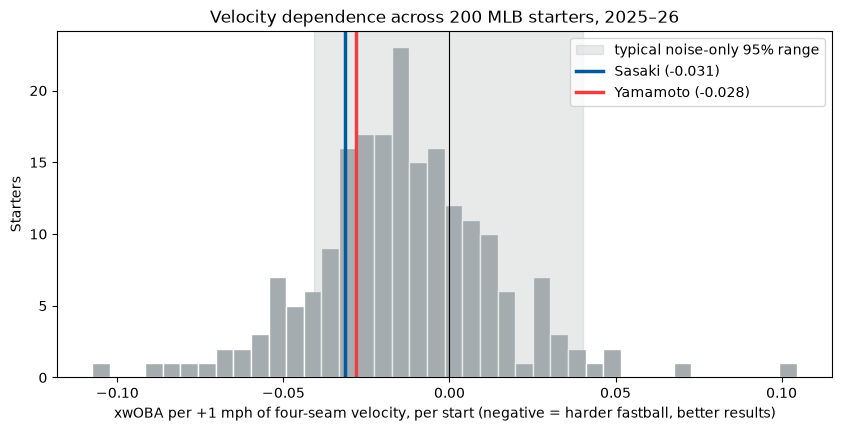

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5))
vals = P.slope_raw
ax.hist(vals, bins=40, color="#A5ACAF", edgecolor="white")
band = (P.null_lo_raw.median(), P.null_hi_raw.median())
ax.axvspan(*band, color="#A5ACAF", alpha=0.25, label="typical noise-only 95% range")
for pid, color, label in [(SASAKI, "#005A9C", "Sasaki"), (YAMAMOTO, "#EF3E42", "Yamamoto")]:
    v = P.loc[P.player_id == pid, "slope_raw"].iloc[0]
    ax.axvline(v, color=color, lw=2.5, label=f"{label} ({v:+.3f})")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("xwOBA per +1 mph of four-seam velocity, per start (negative = harder fastball, better results)")
ax.set_ylabel("Starters")
ax.set_title(f"Velocity dependence across {len(P)} MLB starters, 2025–26")
ax.legend()
fig.savefig(FIG / "s8_league_velocity_dependence.png", dpi=150, bbox_inches="tight")